In [ ]:

import os
import sys
sys.path.append(os.path.dirname(os.path.dirname(__file__)))
from configs.config import * # directories + constants

import mne
import matplotlib

from utils import raw
from utils.ica import get_outFilePaths, get_blockwise_outFilePaths
from utils.subj import get_MEG_raw_subjects
import subprocess
from pathlib import Path

os.environ["MNE_BROWSER_BACKEND"] = "matplotlib"
mne.viz.set_browser_backend("matplotlib")

%matplotlib widget
import matplotlib.pyplot as plt
import mne

mne.set_config("MNE_BROWSER_BACKEND", "matplotlib")
mne.set_config("MNE_BROWSE_RAW_SIZE", "6,1")
mne.set_config("MNE_BROWSE_RAW_SCALE", "0.5")

Using matplotlib as 2D backend.


/tmp/ipykernel_1185899/2896054333.py:24: RuntimeWarning: Setting non-standard config type: "MNE_BROWSE_RAW_SCALE"
  mne.set_config("MNE_BROWSE_RAW_SCALE", "0.5")


open folder with rejected comp files no the side

In [2]:
# ica_folder = 'ica_qc_099cmp'
# ica_folder = 'ica_qc_095cmp'
ica_folder = 'ica_qc_blockwise2'
# ica_folder = 'ica_qc_095_Infomax'
folder_rejectedComps = f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}/step3_rejected_comps"
folder_topoPlots = f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}/step3_comps_topos"
# folder_rejectedComps = f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}/old_step3_rejected_comps"
# folder_topoPlots = f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}/old_step3_comps_topos"

subprocess.Popen(["code", "--new-window", folder_rejectedComps])
subprocess.Popen(["code", "--new-window", folder_topoPlots])
plt.close('all')

In [3]:
# block-wise subjects
all_subjects = [
#  '19910703eigl',
#  '19910823ssld',
#  '19960630cahi',
 '19970302urmr',
#  '19971028mrhs',
#  '19990810mrkh',
#  '20000107ptfu',
#  '20031022ekse',
#  '20070324hlti'
 '20040819knee',
 ]

# ---------------------------- subjects where I tried block.wise ICA - part 1: (subj where I tried the normal ICA before)
# all_subjects = [
# # 	'19960531hibu',
# # 	'20000118sbnb',
# # 	'20040819knee',
# #  '20050204vrao',
# # '20040627vrrj',
# 	# '20050610atbu',
# 	'20040630gbaf'
#  ]

blockNames =  [	
				'block_01',
				'block_02',
				'block_03',
				'block_04',
				'block_05',
				'block_06',
				'block_07',
				'block_08',
				'block_09',
				'block_10',
				'block_11',
				'block_12',
	 ]

load data

Subject ID: 19970302urmr
Opening raw data file /home/reabt/experiments/ncc/MEG/data/ica_qc_blockwise2/step2_ica_tmp_data/19970302urmr_block_01_ica_data.fif...


/tmp/ipykernel_1185899/4165355506.py:29: RuntimeWarning: This filename (/home/reabt/experiments/ncc/MEG/data/ica_qc_blockwise2/step2_ica_tmp_data/19970302urmr_block_01_ica_data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(rawFile, preload=False)


    Range : 9000 ... 106759 =     45.000 ...   533.795 secs
Ready.
Reading /home/reabt/experiments/ncc/MEG/data/ica_qc_blockwise2/step2_ica_comps/19970302urmr_block_01_ica.fif ...
Now restoring ICA solution ...
Ready.
Creating RawArray with float64 data, n_channels=78, n_times=97760
    Range : 9000 ... 106759 =     45.000 ...   533.795 secs
Ready.


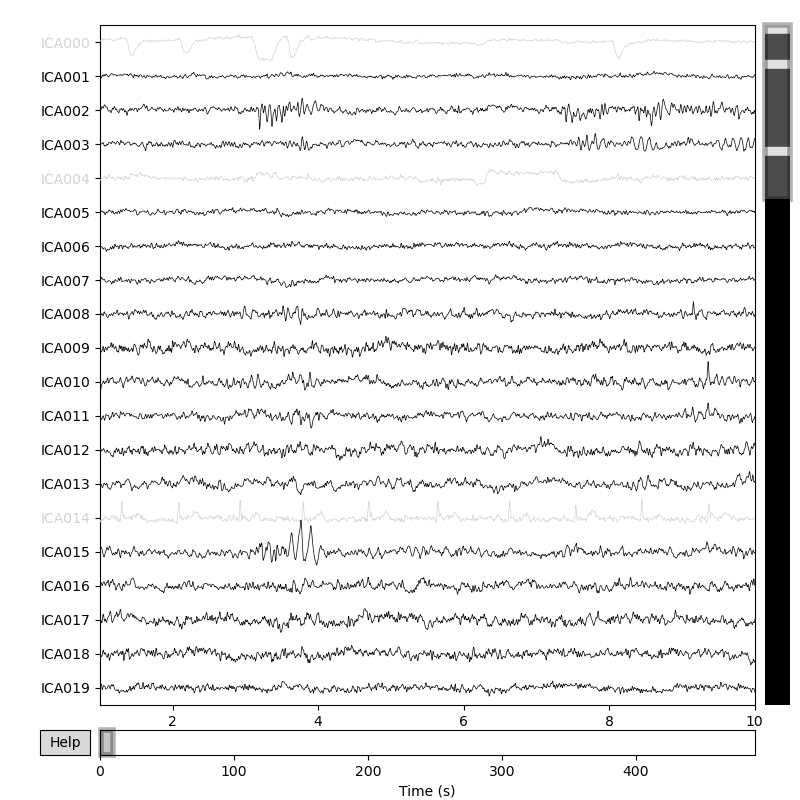

In [7]:

subjNr =0
blockNr = 1

plt.close('all')
# all_subjects = get_MEG_raw_subjects()
blockNr = blockNr -1
# subject_id = all_subjects[all_subjects.index('19880331igse')]
# subject_id = all_subjects[all_subjects.index('19910823ssld')]
# subject_id = all_subjects[15]
# subject_id = all_subjects[30]
subject_id = all_subjects[subjNr]
# subject_id = '19951227eipo'
print(f"Subject ID: {subject_id}")

# _, icaPaths = get_outFilePaths(subject_id, out_root="/home/reabt/experiments/ncc/MEG/data/ica_qc")
# _, icaPaths = get_outFilePaths(subject_id, out_root=f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}")
# rawFile = icaPaths[blocks[0]]['file_icaData']
# icaFile = icaPaths[blocks[0]]['file_ica']


_, icaPaths = get_blockwise_outFilePaths(subject_id, out_root=f"/home/reabt/experiments/ncc/MEG/data/{ica_folder}", block_indices=[blockNr+1])
icaPaths['blocks'][blockNames[blockNr]]

rawFile = icaPaths['blocks'][blockNames[blockNr]]['file_icaData']
icaFile = icaPaths['blocks'][blockNames[blockNr]]['file_ica']

# rawFile = f'/home/reabt/experiments/ncc/MEG/data/ica_qc_blockwise/step1_raw_continuous/{subject_id}_block_00_raw.fif'

raw = mne.io.read_raw_fif(rawFile, preload=False)
ica = mne.preprocessing.read_ica(icaFile)
# raw = raw.filter(l_freq = None , h_freq=40.0, n_jobs=-1)
fig = ica.plot_sources(
    raw,
    show=True,
    block=False,
	# overview_mode=False,
    start = 1,
    stop = 10,   
)


Effective window size : 2.000 (s)
Not setting metadata
226 matching events found
No baseline correction applied
0 projection items activated


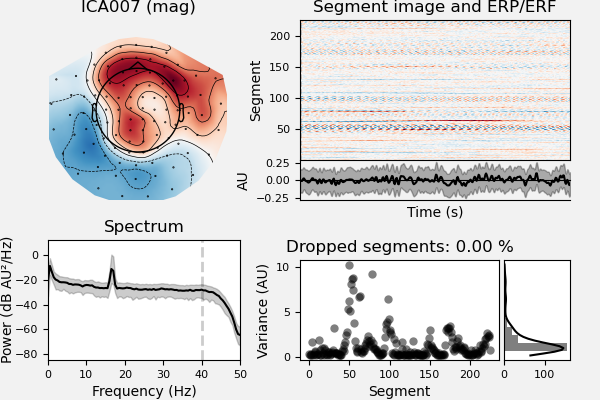

In [57]:
a = ica.plot_properties(
	raw, picks = [7],
	figsize = (6, 4), psd_args={'method': 'welch'})


In [ ]:

# a = ica.plot_properties(
# 	raw, picks = range(31, 50),
# 	figsize = (6, 4), psd_args={'method': 'welch'})


In [34]:
comp = [35, 37, 39, 40 , 46]
ica.get_explained_variance_ratio(raw.load_data(), components = comp)

Reading 0 ... 98390  =      0.000 ...   491.950 secs...


{'mag': np.float64(0.036517901216486126),
 'grad': np.float64(0.06403223235672295)}